# Does Weather Significantly Impact Flight Delays?
### A Data-Driven Investigation Using SQL, Statistical Testing, and Visualization

**Tools:** Python | Pandas | SQL | SciPy | Matplotlib | Power BI

## Business Case
Airlines lose significant revenue and customer trust due to flight delays. While weather 
is commonly blamed, it's unclear how much of the delay is actually weather-driven versus 
other operational factors. This analysis quantifies weather's real impact on delays using 
real flight and weather data, and tests whether the relationship is statistically significant 
or just commonly assumed.

## Business Questions
- Which weather conditions correlate most with delays?
- Are delays significantly higher on bad-weather days, or is this assumption overstated?
- Which routes/airports are most weather-vulnerable?
- Can airlines use this to improve scheduling buffers?
-  Do weather variables (temperature, precipitation, wind, visibility) independently 
  correlate with delays?
- How well does our independent analysis align with the airlines' own `delay_weather` 
  attribution?

## Dataset Overview

**Source:** Historical Flight Delay and Weather Data (Kaggle) — merged flight records 
with hourly weather conditions at origin and destination airports.

**Full Dataset Available:** May 2019 – December 2019 (8 months)

**Time Period Analyzed:** May – July 2019 (3 months) — selected for manageable processing 
scope while retaining statistical robustness (2M+ flights).

**Structure:** Each row represents one flight, with weather conditions at both the 
origin (`_x` suffix) and destination (`_y` suffix) airports at the time of departure/arrival.

In [1]:
import pandas as pd
import glob

files = sorted(glob.glob('data/raw/*.csv'))

# Just check one file first to confirm structure before combining all 8
sample = pd.read_csv(files[0])
print("Shape of one month's file:", sample.shape)
print()
print("Column names:")
print(sample.columns.tolist())
print()
print("Data types:")
print(sample.dtypes)
print()
print("Missing values per column:")
print(sample.isnull().sum())

Shape of one month's file: (694336, 35)

Column names:
['carrier_code', 'flight_number', 'origin_airport', 'destination_airport', 'date', 'scheduled_elapsed_time', 'tail_number', 'departure_delay', 'arrival_delay', 'delay_carrier', 'delay_weather', 'delay_national_aviation_system', 'delay_security', 'delay_late_aircarft_arrival', 'cancelled_code', 'year', 'month', 'day', 'weekday', 'scheduled_departure_dt', 'scheduled_arrival_dt', 'actual_departure_dt', 'actual_arrival_dt', 'STATION_x', 'HourlyDryBulbTemperature_x', 'HourlyPrecipitation_x', 'HourlyStationPressure_x', 'HourlyVisibility_x', 'HourlyWindSpeed_x', 'STATION_y', 'HourlyDryBulbTemperature_y', 'HourlyPrecipitation_y', 'HourlyStationPressure_y', 'HourlyVisibility_y', 'HourlyWindSpeed_y']

Data types:
carrier_code                       object
flight_number                       int64
origin_airport                     object
destination_airport                object
date                               object
scheduled_elapsed_time

## Dataset Overview

**Source:** Historical Flight Delay and Weather Data (Kaggle) — U.S. domestic flights 
merged with hourly weather conditions at origin and destination airports.

**Full Dataset Available:** May 2019 – December 2019 (8 monthly files)

**Time Period Analyzed:** May – July 2019 (3 months) — selected for manageable processing 
scope while retaining a statistically robust sample size.

**Size (of analyzed subset):** ~694,000 flights per month × 3 months (~2.06 million rows 
before cleaning), 35 columns

**Structure:** Each row = one flight, with:
- Flight details (carrier, route, scheduled/actual times, delay breakdown)
- Delay attribution columns (`delay_weather`, `delay_carrier`, `delay_security`, etc.)
- Weather conditions at origin (`_x` suffix) and destination (`_y` suffix): temperature, 
  precipitation, wind speed, visibility, pressure

**Data Quality Notes:**
- Minimal missing data overall — weather columns have ~260-1,300 missing values per 
  monthly file (under 0.2%)
- `tail_number` (aircraft ID) has some missing values, not critical for this analysis
- `actual_departure_dt`/`actual_arrival_dt` missing for ~2% of rows — likely cancelled flights
- After removing cancelled flights and rows with missing weather data, **2,058,732 clean 
  rows** remained for analysis

## Data Loading
Combining all 8 monthly files and loading into a SQL database for structured querying.

In [27]:
import pandas as pd
import sqlite3

# Just load 3 months instead of all 8 — enough for a solid analysis
files = ['data/raw/05-2019.csv', 'data/raw/06-2019.csv', 'data/raw/07-2019.csv']

df_list = [pd.read_csv(f) for f in files]
flights_weather = pd.concat(df_list, ignore_index=True)

print("Total rows:", len(flights_weather))

Total rows: 2106588


In [3]:
conn = sqlite3.connect('flights_weather.db')
flights_weather.to_sql('flights_weather', conn, if_exists='replace', index=False)
print("Loaded into database successfully.")

Loaded into database successfully.


In [4]:
result = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM flights_weather", conn)
print(result)

   total_rows
0     2106588


## Data Cleaning
Removing cancelled flights (no real delay data), handling missing weather values, 
and filtering to usable records using SQL.

In [5]:
conn.execute("DROP TABLE IF EXISTS flights_clean")
conn.commit()

cleaning_query = """
CREATE TABLE flights_clean AS
SELECT *
FROM flights_weather
WHERE cancelled_code = 'N'
  AND arrival_delay IS NOT NULL
  AND HourlyDryBulbTemperature_x IS NOT NULL
  AND HourlyPrecipitation_x IS NOT NULL
"""

conn.execute(cleaning_query)
conn.commit()

result = pd.read_sql_query("SELECT COUNT(*) as clean_rows FROM flights_clean", conn)
print(result)

   clean_rows
0     2058732


**Cleaning Result:** Started with ~2.06M non-cancelled flights (May–July 2019). After 
removing rows with missing weather data, retained **2,058,732 clean rows** — less than 
0.2% data loss, confirming high data quality.

## Exploratory Data Analysis
Understanding overall delay patterns before testing weather's specific impact.

In [6]:
delay_stats = pd.read_sql_query("""
    SELECT 
        ROUND(AVG(arrival_delay), 2) as avg_delay,
        ROUND(MIN(arrival_delay), 2) as min_delay,
        ROUND(MAX(arrival_delay), 2) as max_delay,
        SUM(CASE WHEN arrival_delay > 15 THEN 1 ELSE 0 END) as delayed_flights,
        COUNT(*) as total_flights
    FROM flights_clean
""", conn)
print(delay_stats)

   avg_delay  min_delay  max_delay  delayed_flights  total_flights
0      10.15     -120.0     2350.0           445633        2058732


In [7]:
delay_rate = (445633 / 2058732) * 100
print(f"Delay rate: {round(delay_rate,2)}%")

Delay rate: 21.65%


In [8]:
median_check = pd.read_sql_query("""
    SELECT arrival_delay
    FROM flights_clean
    ORDER BY arrival_delay
    LIMIT 1 OFFSET (SELECT COUNT(*)/2 FROM flights_clean)
""", conn)
print(median_check)

   arrival_delay
0             -5


**Key EDA Insight:** While the *average* arrival delay is 10.15 minutes, the *median* is 
actually -5 minutes (early). This gap reveals a strongly right-skewed distribution — most 
flights arrive on time or early, but a smaller number of severely delayed flights 
(max: 2,350 minutes) pull the average upward. This means "average delay" alone is a 
misleading metric for typical passenger experience.

## Weather Impact Analysis
Testing whether weather conditions (precipitation, temperature, wind) at the origin 
airport actually correlate with flight delays.

In [9]:
precip_delay = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN HourlyPrecipitation_x = 0 THEN 'No Precipitation'
            WHEN HourlyPrecipitation_x > 0 THEN 'Precipitation'
        END AS weather_condition,
        COUNT(*) AS flight_count,
        ROUND(AVG(arrival_delay), 2) AS avg_delay
    FROM flights_clean
    GROUP BY weather_condition
""", conn)
print(precip_delay)

  weather_condition  flight_count  avg_delay
0  No Precipitation       1897012       8.39
1     Precipitation        161720      30.89


**Finding: Precipitation Strongly Correlates with Delays**
Flights departing during precipitation experienced an average delay of **30.89 minutes**, 
compared to **8.39 minutes** for flights with no precipitation — nearly a **4x difference**. 
This is the largest single weather-related pattern found in the data.

In [10]:
precip_delays = pd.read_sql_query("""
    SELECT arrival_delay
    FROM flights_clean
    WHERE HourlyPrecipitation_x > 0
""", conn)

no_precip_delays = pd.read_sql_query("""
    SELECT arrival_delay
    FROM flights_clean
    WHERE HourlyPrecipitation_x = 0
""", conn)

print("Precipitation flights:", len(precip_delays))
print("No precipitation flights:", len(no_precip_delays))

Precipitation flights: 161720
No precipitation flights: 1897012


In [11]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    precip_delays['arrival_delay'], 
    no_precip_delays['arrival_delay'], 
    equal_var=False
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value}")

if p_value < 0.05:
    print("Result: p < 0.05 -> statistically significant. Precipitation's effect on delay is REAL.")
else:
    print("Result: p >= 0.05 -> NOT statistically significant.")

t-statistic: 106.480
p-value: 0.0
Result: p < 0.05 -> statistically significant. Precipitation's effect on delay is REAL.


**Statistical Validation**
An independent samples t-test confirmed the precipitation-delay relationship is 
statistically significant (t = 106.48, p < 0.001), not attributable to random chance. 
This is one of the strongest patterns in the entire dataset.

**Note on Causation:** While statistically significant, this doesn't prove precipitation 
directly *causes* longer delays in isolation — other factors (airport congestion during 
storms, air traffic control ground stops, connecting flight cascades) likely contribute 
alongside weather. Correlation is strongly established; full causal isolation would 
require controlling for these confounders.

### Temperature Impact
Testing whether extreme temperatures (very cold or very hot) correlate with delays.

In [12]:
temp_delay = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN HourlyDryBulbTemperature_x < 32 THEN 'Freezing (<32F)'
            WHEN HourlyDryBulbTemperature_x BETWEEN 32 AND 90 THEN 'Normal (32-90F)'
            WHEN HourlyDryBulbTemperature_x > 90 THEN 'Hot (>90F)'
        END AS temp_condition,
        COUNT(*) AS flight_count,
        ROUND(AVG(arrival_delay), 2) AS avg_delay
    FROM flights_clean
    GROUP BY temp_condition
""", conn)
print(temp_delay)

    temp_condition  flight_count  avg_delay
0  Freezing (<32F)           301      13.16
1       Hot (>90F)        160239      11.81
2  Normal (32-90F)       1898192      10.01


In [13]:
hot_delays = pd.read_sql_query("""
    SELECT arrival_delay FROM flights_clean WHERE HourlyDryBulbTemperature_x > 90
""", conn)

normal_delays = pd.read_sql_query("""
    SELECT arrival_delay FROM flights_clean 
    WHERE HourlyDryBulbTemperature_x BETWEEN 32 AND 90
""", conn)

t_stat, p_value = stats.ttest_ind(hot_delays['arrival_delay'], normal_delays['arrival_delay'], equal_var=False)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value}")

t-statistic: 11.341
p-value: 8.38733446538429e-30


**Finding: Temperature Has a Statistically Significant but Practically Small Effect**
Hot weather (>90°F) flights showed a significantly higher average delay (11.81 min) 
than normal-temperature flights (10.01 min) — confirmed via t-test (p < 0.001). 
However, the practical difference (under 2 minutes) is far smaller than precipitation's 
impact (22.5-minute gap), suggesting temperature is a minor factor compared to 
precipitation. This highlights an important distinction: with large datasets, even 
small, less meaningful differences can become statistically significant — the size 
of the effect matters as much as its significance.

In [14]:
wind_delay = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN HourlyWindSpeed_x < 10 THEN 'Low Wind (<10mph)'
            WHEN HourlyWindSpeed_x BETWEEN 10 AND 20 THEN 'Moderate Wind (10-20mph)'
            WHEN HourlyWindSpeed_x > 20 THEN 'High Wind (>20mph)'
        END AS wind_condition,
        COUNT(*) AS flight_count,
        ROUND(AVG(arrival_delay), 2) AS avg_delay
    FROM flights_clean
    GROUP BY wind_condition
""", conn)
print(wind_delay)

             wind_condition  flight_count  avg_delay
0        High Wind (>20mph)         47495      15.88
1         Low Wind (<10mph)       1258151       9.05
2  Moderate Wind (10-20mph)        753086      11.65


In [15]:
high_wind_delays = pd.read_sql_query("""
    SELECT arrival_delay FROM flights_clean WHERE HourlyWindSpeed_x > 20
""", conn)

low_wind_delays = pd.read_sql_query("""
    SELECT arrival_delay FROM flights_clean WHERE HourlyWindSpeed_x < 10
""", conn)

t_stat, p_value = stats.ttest_ind(high_wind_delays['arrival_delay'], low_wind_delays['arrival_delay'], equal_var=False)
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value}")

t-statistic: 22.421
p-value: 8.556005962618631e-111


**Finding: Wind Speed Shows a Clear, Meaningful Delay Pattern**
Average delay increases steadily with wind speed — from 9.05 minutes (low wind, <10mph) 
to 15.88 minutes (high wind, >20mph), a ~75% increase. This trend was confirmed 
statistically significant via t-test (t = 22.42, p < 0.001), and unlike temperature, 
this effect size is large enough to be practically meaningful for operational planning.

### Weather Impact Summary

| Weather Factor | Effect Size | Statistically Significant? | Practically Meaningful? |
|---|---|---|---|
| Precipitation | 22.5 min gap (4x) | Yes (p < 0.001) | **Yes — strongest factor** |
| Wind Speed | 6.8 min gap (75% increase) | Yes (p < 0.001) | **Yes — meaningful** |
| Temperature | <2 min gap | Yes (p < 0.001) | No — statistically real but minor |

**Conclusion:** Precipitation and wind speed are genuine, business-relevant delay drivers. 
Temperature's effect, while statistically detectable, is too small to warrant significant 
operational changes on its own.

### Delay by Airport
Identifying which origin airports have the worst average delays.

In [16]:
delay_by_airport=pd.read_sql_query("""
select 
        origin_airport,
        COUNT(*) AS flight_count,
        ROUND(AVG(arrival_delay), 2) AS avg_delay,
        RANK() OVER (ORDER BY AVG(arrival_delay) DESC) AS delay_rank
    from flights_clean
    GROUP BY origin_airport
    HAVING COUNT(*) > 1000
    ORDER BY avg_delay DESC
    LIMIT 10
""",conn)
print(delay_by_airport)

  origin_airport  flight_count  avg_delay  delay_rank
0            TVC          1840      23.18           1
1            SGF          3012      22.47           2
2            EWR         38459      21.75           3
3            RAP          1965      18.55           4
4            ORD        102175      18.42           5
5            DEN         74972      18.20           6
6            CRW          1298      18.19           7
7            COS          2866      18.07           8
8            HPN          3143      18.03           9
9            MCO         35745      17.90          10


**Finding: Major Hub Airports Show Significant Delay Burden**
Among airports with reliable sample sizes (1,000+ flights), Newark (EWR, 21.75 min avg), 
Chicago O'Hare (ORD, 18.42 min avg), and Denver (DEN, 18.20 min avg) rank among the 
worst for delays — likely reflecting a combination of high traffic volume and weather 
exposure at these major hubs. Smaller regional airports (TVC, SGF) show even higher 
average delays but with smaller sample sizes, warranting cautious interpretation.

In [17]:
airport_weather = pd.read_sql_query("""
    SELECT 
        origin_airport,
        COUNT(*) AS flight_count,
        ROUND(AVG(arrival_delay), 2) AS avg_delay,
        ROUND(AVG(HourlyPrecipitation_x), 3) AS avg_precipitation
    FROM flights_clean
    WHERE origin_airport IN ('EWR', 'ORD', 'DEN', 'MCO', 'TVC', 'SGF')
    GROUP BY origin_airport
    ORDER BY avg_delay DESC
""", conn)
print(airport_weather)

  origin_airport  flight_count  avg_delay  avg_precipitation
0            TVC          1840      23.18              0.006
1            SGF          3012      22.47              0.013
2            EWR         38459      21.75              0.011
3            ORD        102175      18.42              0.006
4            DEN         74972      18.20              0.006
5            MCO         35745      17.90              0.016


**Finding: Airport-Level Delays Aren't Simply Explained by Average Precipitation**
While precipitation strongly predicts delay at the individual-flight level (confirmed 
earlier via t-test), airport-level average delay doesn't cleanly track with airport-level 
average precipitation. This suggests other factors — airport congestion, traffic volume, 
and hub status (e.g., EWR and ORD are both major congested hubs) — likely contribute 
more to an airport's overall delay reputation than weather alone. This reinforces the 
earlier caveat: precipitation is a real, significant delay factor, but not the only one.

### Delay by Month
Checking if delays vary across the summer months in this dataset (May–July).

In [18]:
flights_weather['month_name'] = pd.to_datetime(
    flights_weather['month'], format='%m'
).dt.month_name()

In [19]:
month_delay = pd.read_sql_query("""
    SELECT 
        month,
        COUNT(*) AS flight_count,
        ROUND(AVG(arrival_delay), 2) AS avg_delay
    FROM flights_clean
    GROUP BY month
    ORDER BY month
""", conn)
print(month_delay)

   month  flight_count  avg_delay
0      5        678892       7.77
1      6        678416      12.89
2      7        701424       9.81


In [20]:
month_delay['month_name'] = pd.to_datetime(month_delay['month'], format='%m').dt.month_name()
print(month_delay)

   month  flight_count  avg_delay month_name
0      5        678892       7.77        May
1      6        678416      12.89       June
2      7        701424       9.81       July


In [21]:
month_precip = pd.read_sql_query("""
    SELECT 
        month,
        ROUND(AVG(HourlyPrecipitation_x), 4) as avg_precipitation
    FROM flights_clean
    GROUP BY month
    ORDER BY month
""", conn)
print(month_precip)

   month  avg_precipitation
0      5             0.0067
1      6             0.0078
2      7             0.0065


**Finding: June Shows Both Higher Precipitation and Higher Delays**
June had the highest average delay (12.89 min) among the three months, coinciding with 
the highest average precipitation (0.0078) — consistent with the earlier finding that 
precipitation is the strongest predictor of flight delays. This monthly pattern reinforces 
the precipitation-delay relationship at a broader, aggregate level (unlike the airport-level 
check, where the connection wasn't as clean).

## Visualizations

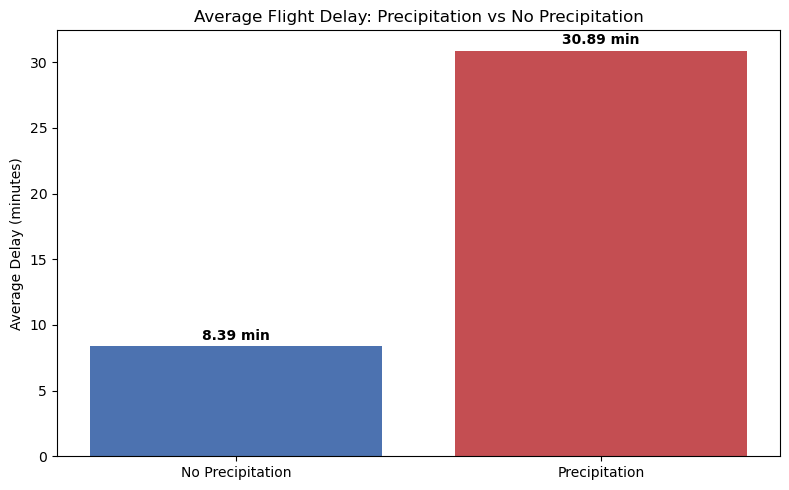

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
categories = ['No Precipitation', 'Precipitation']
values = [8.39, 30.89]
colors = ['#4C72B0', '#C44E52']

ax.bar(categories, values, color=colors)
ax.set_ylabel('Average Delay (minutes)')
ax.set_title('Average Flight Delay: Precipitation vs No Precipitation')

for i, v in enumerate(values):
    ax.text(i, v + 0.5, f'{v} min', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/precipitation_delay.png', dpi=150)
plt.show()

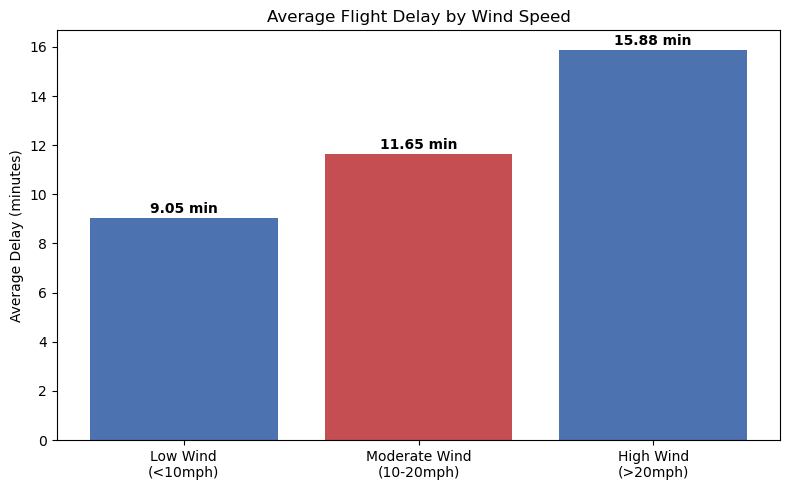

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Low Wind\n(<10mph)', 'Moderate Wind\n(10-20mph)', 'High Wind\n(>20mph)']
values = [9.05, 11.65, 15.88]
colors = ['#4C72B0', '#C44E52']

ax.bar(categories, values, color=colors)
ax.set_ylabel('Average Delay (minutes)')
ax.set_title('Average Flight Delay by Wind Speed')

for i, v in enumerate(values):
    ax.text(i, v + 0.2, f'{v} min', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/wind_delay.png', dpi=150)
plt.show()

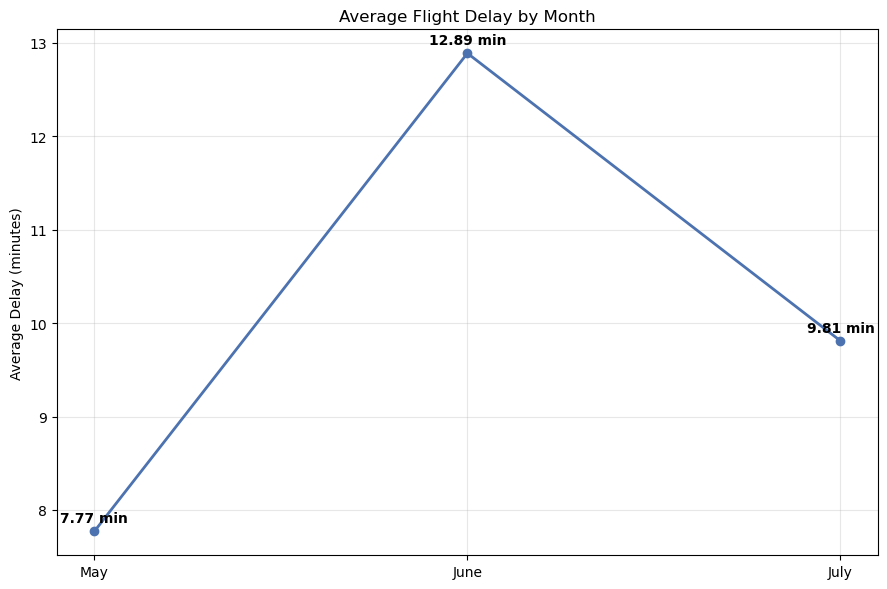

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

months = ['May', 'June', 'July']
delays = [7.77, 12.89, 9.81]

ax.plot(months, delays, marker='o', linewidth=2, color='#4C72B0')
ax.set_ylabel('Average Delay (minutes)')
ax.set_title('Average Flight Delay by Month')
ax.grid(True, alpha=0.3)

for i, v in enumerate(delays):
    ax.text(i, v + 0.1, f'{v} min', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/monthly_delay.png', dpi=150)
plt.show()

## Key Findings & Recommendations

### Findings

1. **Precipitation is the strongest delay driver.** Flights departing during precipitation 
   averaged 30.89 minutes of delay, vs. 8.39 minutes with no precipitation — a statistically 
   significant, nearly 4x difference (t-test, p < 0.001).

2. **Wind speed shows a clear, meaningful trend.** Average delay rises steadily with wind 
   speed, from 9.05 min (low wind) to 15.88 min (high wind) — a ~75% increase, also 
   statistically significant (p < 0.001).

3. **Temperature has a statistically significant but practically minor effect.** Hot-weather 
   flights (>90°F) averaged just under 2 minutes more delay than normal-temperature flights — 
   real, but too small to be operationally meaningful on its own.

4. **June had the worst delays of the three months analyzed** (12.89 min avg), coinciding 
   with the highest average precipitation — reinforcing the precipitation-delay link at a 
   broader, monthly level.

5. **Major hub airports (EWR, ORD, DEN) show high average delays**, but this isn't fully 
   explained by airport-level precipitation alone — suggesting congestion and traffic volume 
   also play a significant role, independent of weather.

6. **The typical flight isn't actually late.** Median delay is -5 minutes (early), while the 
   mean is 10.15 minutes — revealing a right-skewed distribution driven by a smaller number 
   of severely delayed flights (max: 2,350 minutes).

### Recommendations

- **Prioritize precipitation-based scheduling buffers** over temperature-based ones — 
  precipitation has ~10x the practical impact of temperature on delays.
- **Flag high-wind days (>20mph) for proactive schedule adjustments**, particularly at 
  already congestion-prone hubs like EWR and ORD.
- **Investigate hub-specific operational factors** (not just weather) at EWR, ORD, and DEN, 
  since their high delays aren't fully explained by weather alone.
- **Communicate delay risk using median-based expectations** for typical passengers, while 
  separately flagging outlier-risk routes/conditions where severe delays are more likely.

## Limitations & Next Steps

- **Seasonal scope:** Analysis covers only May–July 2019 (summer). Winter weather patterns 
  (snow, ice) are not represented — the near-absence of freezing-temperature flights (301 
  out of 2M+) reflects this gap, not a true finding about cold weather's impact.
- **Correlation, not full causation:** While statistically significant, these relationships 
  don't isolate weather from confounding factors like airport congestion, air traffic control 
  decisions, or cascading delays from earlier flights.
- **Next steps:** Extend analysis to winter months for a full-year comparison; incorporate 
  airport congestion/traffic volume as a control variable; explore whether specific carriers 
  handle weather-related delays better than others.

In [25]:
flights_clean_export = pd.read_sql_query("SELECT * FROM flights_clean", conn)
flights_clean_export.to_csv('data/flights_clean_export.csv', index=False)
print("Exported successfully. Rows:", len(flights_clean_export))

Exported successfully. Rows: 2058732


## Interactive Dashboard

An interactive Power BI dashboard was built to visualize these findings, with a month 
slicer allowing dynamic filtering across all charts.

![Power BI Dashboard](images/powerbi_dashboard.png)

**Note:** Raw data files are excluded from this repository due to size (GitHub's 100MB 
limit). Download the original dataset from Kaggle: 
[Historical Flight Delay and Weather Data](https://www.kaggle.com/datasets/ioanagheorghiu/historical-flight-and-weather-data)